# DXF -> Layers `to_draw` / `not_to_draw` -> 3D

Pipeline unique basé sur `test_data_from_dxf.ipynb` et `layer_dwg_classification.ipynb` :
1. lecture d'un DXF + **vue 2D** (matplotlib, **nuage de points** du plan sans interpolation sur arcs/cercles) + **bbox globale** `SCENE_BBOX`,
2. classification binaire des entités (`to_draw` / `not_to_draw`) à partir du nom de layer,
3. export d'un DXF reclassé,
4. construction d'une scène 3D Open3D à partir des entités `to_draw`.

Visualisations intermédiaires (voir `SHOW_3D_PIPELINE`) : même **centrage** et **cadre rouge** = bbox DXF.
- après classification : nuage vert / gris ;
- après export DXF : nuage to_draw seul ;
- après génération des meshes : aperçu d'un sous-ensemble ;
- dernière cellule : scène complète + export.

In [121]:
import math
from pathlib import Path

import ezdxf
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import open3d as o3d

# -------- Paramètres principaux --------
# Fichier DXF source (modifier ce chemin pour un autre fichier local)
INPUT_DXF = Path(r"C:\Users\mvm\open3d_vision\data\67.dxf")
_SRC_DIR = Path(r"C:\Users\mvm\open3d_vision\src")
_STEM = INPUT_DXF.stem.replace(" ", "_")
OUTPUT_DXF = _SRC_DIR / f"{_STEM}_grouped.dxf"
OUTPUT_PLY = _SRC_DIR / f"{_STEM}_to_draw_scene.ply"

WALL_HEIGHT = 30000.0
WALL_THICKNESS = 0.30
COLUMN_HEIGHT = 30000.0
# Le plan XY est en coordonnées monde (très étendu) : sans ça, l'extrusion Z (~3 m) paraît "plate".
Z_VISUAL_SCALE = 12.0
WALL_HEIGHT_VIS = WALL_HEIGHT * Z_VISUAL_SCALE
COLUMN_HEIGHT_VIS = COLUMN_HEIGHT * Z_VISUAL_SCALE
# Visualisation : limite de triangles affichés (0 = pas de limite). L'export PLY reste en pleine résolution.
MAX_TRIANGLES_DISPLAY = 4000000
ARC_RESOLUTION = 24
SPLINE_RESOLUTION = 48

# Catégories issues du notebook de classification
NOT_TO_DRAW_LAYERS = {
    "COUPE", "TERRASSES", "COTATION", "SURFACE", "TEXTE", "PARKING", "LIMITE PARCELLAIRE", "HACHURES"
}

TO_DRAW_KEYWORDS = {
    "MUR", "PORTEUR", "CLOISON", "PORTE", "FENETRE", "ESCALIER", "EXTERIEUR"
}

# Visualisations 3D tout au long du pipeline (désactiver pour exécution batch rapide)
SHOW_3D_PIPELINE = True
VIS_MAX_POINTS_PER_STAGE = 0  # 0 = pas de limite d'affichage (nuages 3D)
VIS_MESH_PREVIEW_COUNT = 300

# Classifieur LSTM sur le nom de calque (voir layer_classifier.py) — filtre « polygones » = LWPOLYLINE
LAYER_NAME_CLASSIFIER_PATH = _SRC_DIR / "layer_name_classifier.keras"
SHOW_3D_MODEL_LWPOLYLINE = True  # nuage 3D vert/gris selon le modèle (LWPOLYLINE uniquement)
USE_MODEL_DRAW_GROUP_FOR_LWPOLYLINE = False  # True = remplace draw_group pour LWPOLYLINE (export + meshes)

# Affichage 2D du plan en début de pipeline (matplotlib) — points uniquement, sans interpolation
SHOW_PLAN_2D = True
PLAN_2D_MAX_POINTS = 0  # 0 = afficher tous les points (pas de sous-échantillonnage)
PLAN_2D_POINT_SIZE = 0.8
PLAN_2D_MIRROR_X = True  # True = même repère que SCENE_BBOX / vues Open3D
PLAN_2D_FIGSIZE = (11, 10)
# Si False : on n'affiche pas la géométrie SPLINE issue de enrich (discrétisation) ; True = tracer ces sommets
PLAN_2D_INCLUDE_SPLINE_VERTICES = False
# Tracé par segments (interpolation arcs) — désactivé par défaut ; voir plot_dxf_plan_2d_from_df
PLAN_2D_MAX_SEGMENTS = 120_000

# Rempli après lecture DXF + enrich_geometry : repère commun pour toutes les vues 3D
SCENE_BBOX = None

print(f"DXF input: {INPUT_DXF}")
print(f"Extrusion Z (murs): {WALL_HEIGHT_VIS} (base {WALL_HEIGHT} × Z_VISUAL_SCALE {Z_VISUAL_SCALE})")
print(f"Hauteur colonnes: {COLUMN_HEIGHT_VIS} (base {COLUMN_HEIGHT} × Z_VISUAL_SCALE)")

DXF input: C:\Users\mvm\open3d_vision\data\67.dxf
Extrusion Z (murs): 360000.0 (base 30000.0 × Z_VISUAL_SCALE 12.0)
Hauteur colonnes: 360000.0 (base 30000.0 × Z_VISUAL_SCALE)


In [122]:
import sys
from pathlib import Path


def _ensure_layer_classifier_import_path():
    d = globals().get("_SRC_DIR")
    if d is None:
        return
    p = str(Path(d).resolve())
    if p not in sys.path:
        sys.path.insert(0, p)


def assign_draw_group_model_lwpolyline(df, model, char2id, layer_list):
    """Colonne draw_group_model : LSTM (layer_classifier) sur le nom de calque, LWPOLYLINE seulement."""
    _ensure_layer_classifier_import_path()
    df = df.copy()
    df["draw_group_model"] = pd.NA
    mask = df["entity_type"].astype(str).str.upper().eq("LWPOLYLINE")
    if model is None or char2id is None or layer_list is None or not mask.any():
        return df
    import layer_classifier as lc

    raw_layers = df.loc[mask, "layer"].map(lambda x: str(x).strip() if pd.notna(x) else "")
    cache = {}
    for lyr in raw_layers.unique():
        pred_label, _, _ = lc.predict_layer(model, lyr, char2id, layer_list)
        cache[lyr] = lc.layer_pred_to_draw_group(pred_label)
    df.loc[mask, "draw_group_model"] = raw_layers.map(cache)
    return df


def _point_xyz(p):
    if p is None:
        return None
    if hasattr(p, "x"):
        return (float(p.x), float(p.y), float(getattr(p, "z", 0.0)))
    if isinstance(p, (list, tuple)) and len(p) >= 2:
        z = p[2] if len(p) > 2 else 0.0
        return (float(p[0]), float(p[1]), float(z))
    return None


def normalize_layer_name(layer_name: str) -> str:
    if layer_name is None:
        return ""
    return str(layer_name).strip().upper().replace("-", " ").replace("_", " ")


def classify_draw_group(layer_name: str) -> str:
    """Retourne 'to_draw' ou 'not_to_draw' selon le nom de layer."""
    norm = normalize_layer_name(layer_name)

    if not norm:
        return "not_to_draw"

    if norm in NOT_TO_DRAW_LAYERS:
        return "not_to_draw"

    if any(k in norm for k in TO_DRAW_KEYWORDS):
        return "to_draw"

    # Heuristique par défaut prudente pour affichage 3D
    return "not_to_draw"


def dxf_to_dataframe(doc):
    msp = doc.modelspace()
    rows = []

    for e in msp:
        row = {
            "entity_type": e.dxftype(),
            "handle": e.dxf.handle,
        }
        for key, value in e.dxfattribs().items():
            row[key] = value
        rows.append(row)

    return pd.DataFrame(rows), msp


def enrich_geometry(df, msp):
    # geometry doit être en dtype object (list/tuple), pas string
    if "geometry" not in df.columns:
        df["geometry"] = pd.Series([None] * len(df), dtype="object")
    else:
        df["geometry"] = df["geometry"].astype("object")

    lw_map = {}
    for e in msp.query("LWPOLYLINE"):
        pts = [(float(x), float(y), 0.0) for x, y, *_ in e]
        if e.closed and pts:
            pts.append(pts[0])
        lw_map[e.dxf.handle] = pts

    spline_map = {}
    for e in msp.query("SPLINE"):
        try:
            tool = e.construction_tool()
            pts = [tuple(tool.point(t)) for t in np.linspace(0, 1, SPLINE_RESOLUTION)]
            if e.closed and pts:
                pts.append(pts[0])
        except Exception:
            pts = []
        spline_map[e.dxf.handle] = pts

    mask_lw = df["entity_type"].astype(str).str.upper().eq("LWPOLYLINE")
    mask_sp = df["entity_type"].astype(str).str.upper().eq("SPLINE")

    df.loc[mask_lw, "geometry"] = df.loc[mask_lw, "handle"].map(lw_map).astype("object")
    df.loc[mask_sp, "geometry"] = df.loc[mask_sp, "handle"].map(spline_map).astype("object")
    return df


def plan_points_from_row(row, arc_n=16):
    """Points 2D/3D du plan DXF en coords Open3D (miroir X comme les murs)."""
    out = []
    et = str(row.get("entity_type", "")).upper()

    def add_p(p):
        q = _point_xyz(p)
        if q:
            x, y, z = q
            out.append([-x, y, z])

    if et == "LINE":
        add_p(row.get("start"))
        add_p(row.get("end"))
    elif et in ("LWPOLYLINE", "SPLINE"):
        geom = row.get("geometry")
        if isinstance(geom, (list, tuple)):
            for p in geom:
                add_p(p)
    elif et == "ARC":
        pc = _point_xyz(row.get("center"))
        r = row.get("radius")
        sa, ea = row.get("start_angle"), row.get("end_angle")
        if pc is not None and r is not None and sa is not None and ea is not None:
            cx, cy, cz = pc
            r = float(r)
            for t in np.linspace(math.radians(float(sa)), math.radians(float(ea)), max(2, arc_n)):
                out.append([-(cx + r * math.cos(t)), cy + r * math.sin(t), cz])
    elif et == "CIRCLE":
        pc = _point_xyz(row.get("center"))
        rr = row.get("radius")
        if pc is not None and rr is not None and not (isinstance(rr, float) and np.isnan(rr)):
            cx, cy, cz = pc
            r = float(rr)
            out.append([-cx, cy, cz])
            for t in np.linspace(0, 2 * math.pi, max(6, arc_n), endpoint=False):
                out.append([-(cx + r * math.cos(t)), cy + r * math.sin(t), cz])
    return out


def collect_plan_xy_points_no_interpolation(row, mirror_x=True, include_spline_vertices=None):
    """
    Coordonnées XY du plan : sommets et extrémités DXF seulement.
    Pas d'échantillonnage le long des arcs ni sur le cercle (uniquement centre pour CIRCLE).
    ARC : 2 points (début et fin d'arc).
    """
    if include_spline_vertices is None:
        include_spline_vertices = globals().get("PLAN_2D_INCLUDE_SPLINE_VERTICES", False)
    out = []
    et = str(row.get("entity_type", "")).upper()

    def add_xy(p):
        q = _point_xyz(p)
        if q:
            x, y, _ = q
            out.append((-x if mirror_x else x, y))

    if et == "LINE":
        add_xy(row.get("start"))
        add_xy(row.get("end"))
    elif et == "LWPOLYLINE":
        geom = row.get("geometry")
        if isinstance(geom, (list, tuple)):
            for p in geom:
                add_xy(p)
    elif et == "SPLINE" and include_spline_vertices:
        geom = row.get("geometry")
        if isinstance(geom, (list, tuple)):
            for p in geom:
                add_xy(p)
    elif et == "ARC":
        pc = _point_xyz(row.get("center"))
        r = row.get("radius")
        sa, ea = row.get("start_angle"), row.get("end_angle")
        if pc is not None and r is not None and sa is not None and ea is not None:
            cx, cy, _ = pc
            r = float(r)
            for ang in (float(sa), float(ea)):
                rad = math.radians(ang)
                x, y = cx + r * math.cos(rad), cy + r * math.sin(rad)
                out.append((-x if mirror_x else x, y))
    elif et == "CIRCLE":
        add_xy(row.get("center"))
    elif et == "POINT":
        add_xy(row.get("location"))
    elif et in ("TEXT", "MTEXT", "INSERT", "ATTDEF"):
        add_xy(row.get("insert"))
    return out


def plot_dxf_plan_2d_points_only_from_df(
    df,
    title="Plan DXF — points uniquement (sans interpolation)",
    mirror_x=None,
    max_points=None,
    figsize=None,
    point_size=None,
    draw_scene_bbox_xy=True,
):
    """Figure matplotlib : nuage de points 2D, sans ajout de points intermédiaires sur les courbes."""
    if not globals().get("SHOW_PLAN_2D", True):
        return
    if mirror_x is None:
        mirror_x = globals().get("PLAN_2D_MIRROR_X", True)
    if max_points is None:
        max_points = globals().get("PLAN_2D_MAX_POINTS", 0)
    if figsize is None:
        figsize = globals().get("PLAN_2D_FIGSIZE", (11, 10))
    if point_size is None:
        point_size = globals().get("PLAN_2D_POINT_SIZE", 0.8)

    pts = []
    for _, row in df.iterrows():
        pts.extend(collect_plan_xy_points_no_interpolation(row, mirror_x=mirror_x))

    if not pts:
        print("[2D] Aucun point à afficher (mode sans interpolation).")
        return

    a = np.asarray(pts, dtype=np.float64)
    n_raw = len(a)
    if max_points and max_points > 0 and len(a) > max_points:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(a), max_points, replace=False)
        a = a[idx]
        print(f"[2D] Affichage : {len(a)} points tirés parmi {n_raw} (plafond {max_points})")

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(
        a[:, 0],
        a[:, 1],
        s=point_size,
        c="#1f4e79",
        alpha=0.45,
        linewidths=0,
        marker=".",
    )
    ax.set_aspect("equal", adjustable="box")
    ax.autoscale()
    ax.set_title(title)
    ax.set_xlabel("X" + (" (miroir = SCENE_BBOX / 3D)" if mirror_x else " (DXF brut)"))
    ax.set_ylabel("Y")
    ax.grid(True, alpha=0.3)

    if draw_scene_bbox_xy:
        bb = globals().get("SCENE_BBOX")
        if isinstance(bb, dict) and "min" in bb and "max" in bb:
            mn, mx = bb["min"], bb["max"]
            w, h = float(mx[0] - mn[0]), float(mx[1] - mn[1])
            ax.add_patch(
                Rectangle(
                    (float(mn[0]), float(mn[1])),
                    w,
                    h,
                    fill=False,
                    edgecolor="red",
                    linewidth=1.0,
                    linestyle="--",
                    label="SCENE_BBOX (XY)",
                )
            )
            ax.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()
    print(f"[2D] Points du plan (sans interpolation arcs/cercles) : {n_raw} collectés, {len(a)} affichés")


def collect_plan_line_segments_2d(df, mirror_x=True, max_segments=120_000):
    """Segments [ (x1,y1), (x2,y2) ] pour LineCollection (projection XY)."""
    segs = []
    for _, row in df.iterrows():
        if len(segs) >= max_segments:
            break
        et = str(row.get("entity_type", "")).upper()
        if et == "LINE":
            s, t = _point_xyz(row.get("start")), _point_xyz(row.get("end"))
            if s and t:
                x1, y1, _ = s
                x2, y2, _ = t
                if mirror_x:
                    x1, x2 = -x1, -x2
                segs.append([(x1, y1), (x2, y2)])
        elif et in ("LWPOLYLINE", "SPLINE"):
            geom = row.get("geometry")
            if isinstance(geom, (list, tuple)) and len(geom) >= 2:
                pts = []
                for p in geom:
                    q = _point_xyz(p)
                    if q:
                        x, y, _ = q
                        pts.append((-x if mirror_x else x, y))
                for i in range(len(pts) - 1):
                    segs.append([pts[i], pts[i + 1]])
        elif et == "ARC":
            pc = _point_xyz(row.get("center"))
            r = row.get("radius")
            sa, ea = row.get("start_angle"), row.get("end_angle")
            if pc is not None and r is not None and sa is not None and ea is not None:
                cx, cy, _ = pc
                r = float(r)
                prev = None
                for t in np.linspace(
                    math.radians(float(sa)), math.radians(float(ea)), max(2, 24)
                ):
                    x, y = cx + r * math.cos(t), cy + r * math.sin(t)
                    xp = -x if mirror_x else x
                    if prev is not None:
                        segs.append([prev, (xp, y)])
                    prev = (xp, y)
        elif et == "CIRCLE":
            pc = _point_xyz(row.get("center"))
            rr = row.get("radius")
            if pc is not None and rr is not None and not (isinstance(rr, float) and np.isnan(rr)):
                cx, cy, _ = pc
                r = float(rr)
                ring = []
                for t in np.linspace(0, 2 * math.pi, 36, endpoint=False):
                    x, y = cx + r * math.cos(t), cy + r * math.sin(t)
                    ring.append((-x if mirror_x else x, y))
                for i in range(len(ring)):
                    segs.append([ring[i], ring[(i + 1) % len(ring)]])
    return segs


def plot_dxf_plan_2d_from_df(
    df,
    title="Plan DXF (XY)",
    mirror_x=None,
    max_segments=None,
    figsize=None,
    draw_scene_bbox_xy=True,
):
    """Figure matplotlib : tracé 2D du plan dès la lecture DXF."""
    if not globals().get("SHOW_PLAN_2D", True):
        return
    if mirror_x is None:
        mirror_x = globals().get("PLAN_2D_MIRROR_X", True)
    if max_segments is None:
        max_segments = globals().get("PLAN_2D_MAX_SEGMENTS", 120_000)
    if figsize is None:
        figsize = globals().get("PLAN_2D_FIGSIZE", (11, 10))

    segs = collect_plan_line_segments_2d(df, mirror_x=mirror_x, max_segments=max_segments)
    if not segs:
        print("[2D] Aucun segment géométrique à afficher.")
        return

    fig, ax = plt.subplots(figsize=figsize)
    lc = LineCollection(segs, colors="#1f4e79", linewidths=0.35, alpha=0.55)
    ax.add_collection(lc)
    ax.set_aspect("equal", adjustable="box")
    ax.autoscale()
    ax.set_title(title)
    ax.set_xlabel("X" + (" (miroir = repère 3D / SCENE_BBOX)" if mirror_x else " (DXF brut)"))
    ax.set_ylabel("Y")
    ax.grid(True, alpha=0.3)

    if draw_scene_bbox_xy:
        bb = globals().get("SCENE_BBOX")
        if isinstance(bb, dict) and "min" in bb and "max" in bb:
            mn, mx = bb["min"], bb["max"]
            w, h = float(mx[0] - mn[0]), float(mx[1] - mn[1])
            ax.add_patch(
                Rectangle(
                    (float(mn[0]), float(mn[1])),
                    w,
                    h,
                    fill=False,
                    edgecolor="red",
                    linewidth=1.0,
                    linestyle="--",
                    label="SCENE_BBOX (XY)",
                )
            )
            ax.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()
    print(f"[2D] Segments affichés: {len(segs)} (plafond {max_segments})")


def compute_dxf_scene_bbox_from_df(df, z_top_for_meshes=None):
    """
    Bbox monde alignée axes, même repère que les meshes (miroir X dans plan_points_from_row).
    z_top_for_meshes : borne haute Z pour inclure l'extrusion des murs (défaut : WALL_HEIGHT_VIS).
    """
    if z_top_for_meshes is None:
        z_top_for_meshes = float(globals().get("WALL_HEIGHT_VIS") or 0.0)
    pts = []
    for _, row in df.iterrows():
        pts.extend(plan_points_from_row(row))
    if not pts:
        return None
    a = np.asarray(pts, dtype=np.float64)
    mn = a.min(axis=0).copy()
    mx = a.max(axis=0).copy()
    mn[2] = min(mn[2], 0.0)
    if z_top_for_meshes > 0:
        mx[2] = max(mx[2], z_top_for_meshes)
    center = (mn + mx) * 0.5
    extent = mx - mn
    return {"min": mn, "max": mx, "center": center, "extent": extent}


def scene_bbox_wireframe_centered(plan_bbox_dict):
    """LineSet de la bbox plan, déjà centrée à l'origine (après translate -center)."""
    mn = np.asarray(plan_bbox_dict["min"], dtype=np.float64)
    mx = np.asarray(plan_bbox_dict["max"], dtype=np.float64)
    c = np.asarray(plan_bbox_dict["center"], dtype=np.float64)
    corners = np.array(
        [
            [mn[0], mn[1], mn[2]],
            [mx[0], mn[1], mn[2]],
            [mx[0], mx[1], mn[2]],
            [mn[0], mx[1], mn[2]],
            [mn[0], mn[1], mx[2]],
            [mx[0], mn[1], mx[2]],
            [mx[0], mx[1], mx[2]],
            [mn[0], mx[1], mx[2]],
        ],
        dtype=np.float64,
    )
    corners = corners - c
    lines = [
        [0, 1], [1, 2], [2, 3], [3, 0],
        [4, 5], [5, 6], [6, 7], [7, 4],
        [0, 4], [1, 5], [2, 6], [3, 7],
    ]
    ls = o3d.geometry.LineSet()
    ls.points = o3d.utility.Vector3dVector(corners)
    ls.lines = o3d.utility.Vector2iVector(np.asarray(lines, dtype=np.int32))
    ls.paint_uniform_color([1.0, 0.15, 0.15])
    return ls


def scene_bbox_xy_wireframe_world(plan_bbox_dict, z_world=0.0):
    """Rectangle du plan (XY) à Z fixe, repère monde — évite un cadre 3D à l'échelle WALL_HEIGHT_VIS."""
    mn = np.asarray(plan_bbox_dict["min"], dtype=np.float64)
    mx = np.asarray(plan_bbox_dict["max"], dtype=np.float64)
    zz = float(z_world)
    pts = [
        [mn[0], mn[1], zz],
        [mx[0], mn[1], zz],
        [mx[0], mx[1], zz],
        [mn[0], mx[1], zz],
    ]
    lines = [[0, 1], [1, 2], [2, 3], [3, 0]]
    ls = o3d.geometry.LineSet()
    ls.points = o3d.utility.Vector3dVector(np.asarray(pts, dtype=np.float64))
    ls.lines = o3d.utility.Vector2iVector(np.asarray(lines, dtype=np.int32))
    ls.paint_uniform_color([1.0, 0.15, 0.15])
    return ls


def show_pipeline_stage(
    geometries,
    title="",
    center=True,
    show_plan_bbox_wireframe=True,
    center_mode="full",
):
    """Affiche géométries + repère ; recentrage sur SCENE_BBOX.
    center_mode: 'full' = centre 3D (meshes extrudés) ; 'plan_xy' = centre XY + Z=0 pour nuages du plan
    (sinon z≈0 devient z≈-WALL_HEIGHT_VIS/2 et la caméra ne voit plus le plan)."""
    if not SHOW_3D_PIPELINE:
        return
    geoms = [g for g in geometries if g is not None]
    if not geoms:
        print(f"[3D] {title} — rien à afficher")
        return
    print(f"[3D] {title}")
    extra = []
    plan_bbox = globals().get("SCENE_BBOX")
    frame_size = 1.0
    if (
        center
        and isinstance(plan_bbox, dict)
        and "center" in plan_bbox
        and np.isfinite(plan_bbox["center"]).all()
    ):
        if center_mode == "plan_xy":
            c_full = np.asarray(plan_bbox["center"], dtype=np.float64)
            c = np.array([c_full[0], c_full[1], 0.0], dtype=np.float64)
            for g in geoms:
                g.translate(-c)
            if show_plan_bbox_wireframe:
                wf = scene_bbox_xy_wireframe_world(plan_bbox, z_world=0.0)
                wf.translate(-c)
                extra.append(wf)
            ex_xy = float(max(plan_bbox["extent"][0], plan_bbox["extent"][1]))
            frame_size = max(0.5, ex_xy * 0.03)
        else:
            c = np.asarray(plan_bbox["center"], dtype=np.float64)
            for g in geoms:
                g.translate(-c)
            if show_plan_bbox_wireframe:
                extra.append(scene_bbox_wireframe_centered(plan_bbox))
            frame_size = max(1.0, float(np.max(plan_bbox["extent"]) * 0.03))
    elif center:
        acc = []
        for g in geoms:
            if isinstance(g, o3d.geometry.PointCloud) and len(g.points) > 0:
                acc.append(np.asarray(g.points))
            elif isinstance(g, o3d.geometry.TriangleMesh) and len(g.vertices) > 0:
                acc.append(np.asarray(g.vertices))
            elif isinstance(g, o3d.geometry.LineSet) and len(g.points) > 0:
                acc.append(np.asarray(g.points))
        if acc:
            allp = np.vstack(acc)
            frame_size = max(1.0, float(np.ptp(allp, axis=0).max() * 0.03))
            c = allp.mean(axis=0)
            for g in geoms:
                g.translate(-c)
    frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=frame_size)
    o3d.visualization.draw_geometries(
        geoms + extra + [frame],
        window_name=title[:80] if title else "Pipeline 3D",
        mesh_show_back_face=True,
    )


def visualize_df_draw_groups(
    df,
    title="Plan : to_draw vs not_to_draw",
    max_points=None,
    group_column="draw_group",
    entity_types=None,
):
    """Nuage coloré : vert = to_draw, gris = not_to_draw.
    group_column : ex. draw_group (heuristique) ou draw_group_model (LSTM sur LWPOLYLINE).
    entity_types : si défini (ex. {"LWPOLYLINE"}), n'affiche que ces types d'entités.
    """
    if not SHOW_3D_PIPELINE:
        return
    if max_points is None:
        max_points = VIS_MAX_POINTS_PER_STAGE
    td_pts, ntd_pts = [], []
    for _, row in df.iterrows():
        if entity_types is not None:
            et = str(row.get("entity_type", "")).upper()
            if et not in entity_types:
                continue
        grp = row.get(group_column)
        if grp is None or pd.isna(grp):
            continue
        pts = plan_points_from_row(row)
        if not pts:
            continue
        if grp == "to_draw":
            td_pts.extend(pts)
        else:
            ntd_pts.extend(pts)

    def subsample(arr, cap):
        a = np.asarray(arr, dtype=np.float64)
        if a.size == 0:
            return a.reshape(0, 3)
        if cap is None or cap <= 0 or len(a) <= cap:
            return a
        rng = np.random.default_rng(0)
        idx = rng.choice(len(a), cap, replace=False)
        return a[idx]

    if max_points and max_points > 0:
        half = max(1000, max_points // 2)
    else:
        half = 0
    pcd_list = []
    a_td = subsample(td_pts, half)
    if len(a_td) > 0:
        p1 = o3d.geometry.PointCloud()
        p1.points = o3d.utility.Vector3dVector(a_td)
        p1.paint_uniform_color([0.15, 0.85, 0.25])
        pcd_list.append(p1)
    a_nt = subsample(ntd_pts, half)
    if len(a_nt) > 0:
        p2 = o3d.geometry.PointCloud()
        p2.points = o3d.utility.Vector3dVector(a_nt)
        p2.paint_uniform_color([0.55, 0.55, 0.58])
        pcd_list.append(p2)
    show_pipeline_stage(pcd_list, title=title, center_mode="plan_xy")


def visualize_meshes_subset(meshes, title="Aperçu meshes (sous-ensemble)", max_meshes=None):
    """Fusionne les N premiers meshes pour un aperçu intermédiaire."""
    if not SHOW_3D_PIPELINE or not meshes:
        return
    if max_meshes is None:
        max_meshes = VIS_MESH_PREVIEW_COUNT
    scene = o3d.geometry.TriangleMesh()
    for m in meshes[: int(max_meshes)]:
        scene += m
    scene.remove_duplicated_vertices()
    scene.remove_degenerate_triangles()
    scene.remove_unreferenced_vertices()
    if len(scene.vertices) == 0 or len(scene.triangles) == 0:
        print(f"[3D] {title} — aucun triangle après fusion")
        return
    scene.compute_vertex_normals()
    show_pipeline_stage([scene], title=title)


def visualize_to_draw_plan_only(df, title="Plan to_draw uniquement", max_points=None):
    """Nuage des seules entités classées to_draw (après export DXF, données identiques)."""
    if not SHOW_3D_PIPELINE:
        return
    if max_points is None:
        max_points = VIS_MAX_POINTS_PER_STAGE
    pts = []
    for _, row in df[df["draw_group"] == "to_draw"].iterrows():
        pts.extend(plan_points_from_row(row))
    a = np.asarray(pts, dtype=np.float64)
    if a.size == 0:
        print(f"[3D] {title} — aucun point")
        return
    if max_points and max_points > 0 and len(a) > max_points:
        rng = np.random.default_rng(1)
        a = a[rng.choice(len(a), max_points, replace=False)]
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(a)
    pcd.paint_uniform_color([0.2, 0.9, 0.35])
    show_pipeline_stage([pcd], title=title, center_mode="plan_xy")

BBox globale DXF (repère Open3D = plan avec miroir X, Z étendu jusqu'à WALL_HEIGHT_VIS):
  min    = [-15.6520462   -4.17224407  -4.81071186]
  max    = [-1.11562614e+01  2.69297099e+00  3.60000000e+05]
  center = [-1.34041538e+01 -7.39636540e-01  1.79997595e+05]
  extent = [4.49578476e+00 6.86521506e+00 3.60004811e+05]


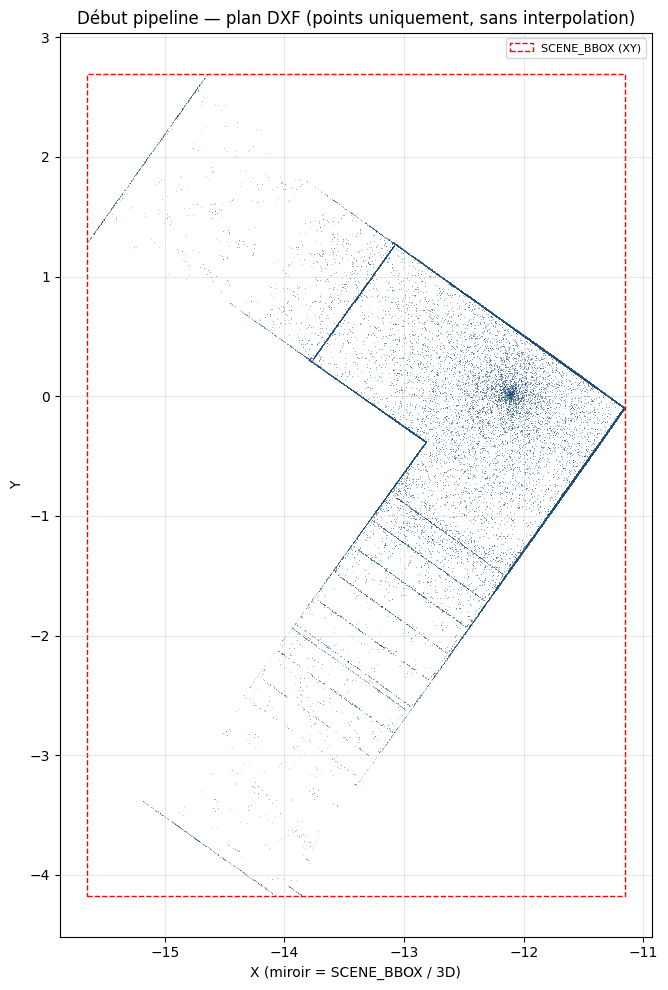

[2D] Points du plan (sans interpolation arcs/cercles) : 118410 collectés, 118410 affichés
Répartition draw_group:
draw_group
not_to_draw    59205
Name: count, dtype: int64

Exemple des layers originaux -> groupés:
 layer  draw_group
POINTS not_to_draw
[3D] Étape 1 — plan : to_draw (vert) vs not_to_draw (gris)


In [123]:
doc = ezdxf.readfile(INPUT_DXF)
df, msp = dxf_to_dataframe(doc)
df = enrich_geometry(df, msp)

# Bbox globale dès la lecture (plan + marge Z pour extrusion murs)
SCENE_BBOX = compute_dxf_scene_bbox_from_df(df)
if SCENE_BBOX is not None:
    print("BBox globale DXF (repère Open3D = plan avec miroir X, Z étendu jusqu'à WALL_HEIGHT_VIS):")
    print(f"  min    = {SCENE_BBOX['min']}")
    print(f"  max    = {SCENE_BBOX['max']}")
    print(f"  center = {SCENE_BBOX['center']}")
    print(f"  extent = {SCENE_BBOX['extent']}")
else:
    print("ATTENTION: aucun point géométrique — SCENE_BBOX=None, vues 3D en mode fallback")

plot_dxf_plan_2d_points_only_from_df(
    df,
    title="Début pipeline — plan DXF (points uniquement, sans interpolation)",
)

# Sécurise le format de la colonne layer
if "layer" not in df.columns:
    df["layer"] = ""
else:
    df["layer"] = df["layer"].fillna("").astype(str)

df["draw_group"] = df["layer"].apply(classify_draw_group)

_ensure_layer_classifier_import_path()
_lstm_model, _char2id, _layer_labels = None, None, None
try:
    import layer_classifier as lc

    _lstm_model, _char2id, _layer_labels = lc.load_keras_layer_classifier(LAYER_NAME_CLASSIFIER_PATH)
except Exception as _e:
    print(f"[NN] layer_classifier indisponible ({_e!r})")

df = assign_draw_group_model_lwpolyline(df, _lstm_model, _char2id, _layer_labels)

if (
    USE_MODEL_DRAW_GROUP_FOR_LWPOLYLINE
    and _lstm_model is not None
    and df["draw_group_model"].notna().any()
):
    _m = df["entity_type"].astype(str).str.upper().eq("LWPOLYLINE") & df["draw_group_model"].notna()
    df.loc[_m, "draw_group"] = df.loc[_m, "draw_group_model"]
    print("draw_group fusionné avec prédiction modèle (LWPOLYLINE).")

df["layer_grouped"] = df["draw_group"]

print("Répartition draw_group:")
print(df["draw_group"].value_counts(dropna=False))

print("\nExemple des layers originaux -> groupés:")
preview = df.loc[:, ["layer", "draw_group"]].drop_duplicates().head(20)
print(preview.to_string(index=False))

visualize_df_draw_groups(
    df,
    title="Étape 1 — plan : to_draw (vert) vs not_to_draw (gris)",
)

if SHOW_3D_MODEL_LWPOLYLINE and _lstm_model is not None:
    _has_lw = df["entity_type"].astype(str).str.upper().eq("LWPOLYLINE").any()
    _has_mod = df["draw_group_model"].notna().any()
    if _has_lw and _has_mod:
        visualize_df_draw_groups(
            df,
            title="Étape 1 (modèle) — LWPOLYLINE : to_draw (vert) vs not_to_draw (gris)",
            group_column="draw_group_model",
            entity_types={"LWPOLYLINE"},
        )
    else:
        print("[3D] Aucune LWPOLYLINE classée par le modèle — vue modèle omise.")
elif SHOW_3D_MODEL_LWPOLYLINE:
    print(
        f"[NN] Modèle absent ({LAYER_NAME_CLASSIFIER_PATH}). "
        "Entraîner et sauvegarder layer_name_classifier.keras (voir layer_classifier.py)."
    )

In [124]:
# Export d'un DXF avec layers réaffectés à to_draw / not_to_draw
handle_to_group = dict(zip(df["handle"], df["draw_group"]))

for e in doc.modelspace():
    group = handle_to_group.get(e.dxf.handle, "not_to_draw")
    e.dxf.layer = group

# Crée explicitement les layers s'ils n'existent pas
if "to_draw" not in doc.layers:
    doc.layers.add("to_draw", color=3)      # vert
if "not_to_draw" not in doc.layers:
    doc.layers.add("not_to_draw", color=8)  # gris

doc.saveas(str(OUTPUT_DXF))
print(f"DXF regroupé exporté : {OUTPUT_DXF}")

visualize_to_draw_plan_only(
    df,
    title="Étape 1b — calque to_draw seul (après export DXF)",
)

DXF regroupé exporté : C:\Users\mvm\open3d_vision\src\67_grouped.dxf
[3D] Étape 1b — calque to_draw seul (après export DXF) — aucun point


In [125]:
def wall_from_line(start, end, height=WALL_HEIGHT_VIS, thickness=WALL_THICKNESS):
    s = _point_xyz(start)
    t = _point_xyz(end)
    if s is None or t is None:
        return None

    x1, y1, _ = s
    x2, y2, _ = t

    # miroir X pour cohérence avec le notebook source
    x1, x2 = -x1, -x2

    direction = np.array([x2 - x1, y2 - y1], dtype=float)
    length = np.linalg.norm(direction)
    if length < 1e-9:
        return None
    direction /= length

    normal = np.array([-direction[1], direction[0]])
    p1 = np.array([x1, y1]) + normal * thickness / 2
    p2 = np.array([x2, y2]) + normal * thickness / 2
    p3 = np.array([x2, y2]) - normal * thickness / 2
    p4 = np.array([x1, y1]) - normal * thickness / 2

    vertices = np.array([
        [*p1, 0], [*p2, 0], [*p3, 0], [*p4, 0],
        [*p1, height], [*p2, height], [*p3, height], [*p4, height],
    ])
    triangles = np.array([
        [0, 1, 2], [0, 2, 3],
        [4, 5, 6], [4, 6, 7],
        [0, 1, 5], [0, 5, 4],
        [1, 2, 6], [1, 6, 5],
        [2, 3, 7], [2, 7, 6],
        [3, 0, 4], [3, 4, 7],
    ])

    mesh = o3d.geometry.TriangleMesh()
    mesh.vertices = o3d.utility.Vector3dVector(vertices)
    mesh.triangles = o3d.utility.Vector3iVector(triangles)
    mesh.compute_vertex_normals()
    return mesh


def wall_from_polyline(points):
    meshes = []
    if not isinstance(points, (list, tuple)) or len(points) < 2:
        return meshes

    for p1, p2 in zip(points[:-1], points[1:]):
        m = wall_from_line(p1, p2)
        if m is not None:
            meshes.append(m)
    return meshes


def column_from_circle(center, radius, height=COLUMN_HEIGHT_VIS):
    c = _point_xyz(center)
    if c is None or radius is None:
        return None
    if isinstance(radius, float) and np.isnan(radius):
        return None

    cx, cy, _ = c
    mesh = o3d.geometry.TriangleMesh.create_cylinder(radius=float(radius), height=height)
    mesh.translate((-cx, cy, height / 2))
    mesh.compute_vertex_normals()
    return mesh


def arc_to_polyline(center, radius, start_angle, end_angle, resolution=ARC_RESOLUTION):
    c = _point_xyz(center)
    if c is None:
        return []
    if radius is None:
        return []

    cx, cy, cz = c
    angles = np.linspace(math.radians(float(start_angle)), math.radians(float(end_angle)), resolution)
    return [(cx + float(radius) * math.cos(a), cy + float(radius) * math.sin(a), cz) for a in angles]

In [126]:
to_draw_df = df[df["draw_group"] == "to_draw"].copy()
print(f"Entités to_draw: {len(to_draw_df)} / {len(df)}")


def _mesh_is_valid(mesh):
    if mesh is None:
        return False
    v = np.asarray(mesh.vertices)
    t = np.asarray(mesh.triangles)
    if v.size == 0 or t.size == 0:
        return False
    return np.isfinite(v).all()


meshes = []
invalid_meshes = 0
for _, row in to_draw_df.iterrows():
    etype = str(row.get("entity_type", "")).upper()

    if etype == "LINE":
        m = wall_from_line(row.get("start"), row.get("end"))
        if _mesh_is_valid(m):
            m.paint_uniform_color([0.70, 0.70, 0.70])
            meshes.append(m)
        elif m is not None:
            invalid_meshes += 1

    elif etype == "LWPOLYLINE":
        pts = row.get("geometry")
        for m in wall_from_polyline(pts):
            if _mesh_is_valid(m):
                m.paint_uniform_color([0.90, 0.70, 0.40])
                meshes.append(m)
            else:
                invalid_meshes += 1

    elif etype == "ARC":
        pts = arc_to_polyline(
            row.get("center"),
            row.get("radius"),
            row.get("start_angle"),
            row.get("end_angle"),
            ARC_RESOLUTION,
        )
        for m in wall_from_polyline(pts):
            if _mesh_is_valid(m):
                m.paint_uniform_color([0.20, 0.60, 0.20])
                meshes.append(m)
            else:
                invalid_meshes += 1

    elif etype == "CIRCLE":
        m = column_from_circle(row.get("center"), row.get("radius"))
        if _mesh_is_valid(m):
            m.paint_uniform_color([0.30, 0.50, 0.80])
            meshes.append(m)
        elif m is not None:
            invalid_meshes += 1

print(f"Meshes valides: {len(meshes)} | invalides ignorés: {invalid_meshes}")

visualize_meshes_subset(
    meshes,
    title=f"Étape 2 — aperçu des {VIS_MESH_PREVIEW_COUNT} premiers meshes to_draw",
)

Entités to_draw: 0 / 59205
Meshes valides: 0 | invalides ignorés: 0


In [127]:
DEBUG_VIS = True


print("[3D] Étape 3 — scène complète (debug PCD + mesh, export PLY)")


def _copy_triangle_mesh(mesh):
    """Copie profonde (Open3D : pas de mesh.clone() sur toutes les versions / builds CUDA)."""
    m = o3d.geometry.TriangleMesh()
    m.vertices = o3d.utility.Vector3dVector(np.asarray(mesh.vertices))
    m.triangles = o3d.utility.Vector3iVector(np.asarray(mesh.triangles))
    if mesh.has_vertex_colors():
        m.vertex_colors = o3d.utility.Vector3dVector(np.asarray(mesh.vertex_colors))
    return m


def _mesh_for_display(mesh, max_triangles):
    """Copie du mesh réduite pour l'affichage si trop de triangles."""
    n = len(mesh.triangles)
    if not max_triangles or int(max_triangles) <= 0 or n <= int(max_triangles):
        return mesh
    vis = _copy_triangle_mesh(mesh)
    try:
        vis = vis.simplify_quadric_decimation(int(max_triangles))
        vis.compute_vertex_normals()
        print(
            f"Affichage: simplification {n} -> {len(vis.triangles)} triangles "
            f"(MAX_TRIANGLES_DISPLAY={max_triangles})"
        )
    except Exception as exc:
        print(f"simplify_quadric_decimation impossible ({exc!r}), affichage mesh complet.")
        return mesh
    return vis


if meshes:
    scene = o3d.geometry.TriangleMesh()
    for m in meshes:
        scene += m

    # Nettoyage pour éviter un rendu vide malgré des triangles comptés
    scene.remove_duplicated_vertices()
    scene.remove_duplicated_triangles()
    scene.remove_degenerate_triangles()
    scene.remove_unreferenced_vertices()

    v = np.asarray(scene.vertices)
    finite_mask = np.isfinite(v).all(axis=1)
    if not finite_mask.all():
        keep_idx = np.where(finite_mask)[0]
        scene = scene.select_by_index(keep_idx)

    if len(scene.vertices) == 0 or len(scene.triangles) == 0:
        print("Scène vide après nettoyage (géométries invalides).")
    else:
        scene.compute_vertex_normals()

        # Debug géométrique avant recentrage
        v0 = np.asarray(scene.vertices)
        mins = v0.min(axis=0)
        maxs = v0.max(axis=0)
        p01 = np.quantile(v0, 0.01, axis=0)
        p99 = np.quantile(v0, 0.99, axis=0)
        print(f"Scene brute: {len(scene.vertices)} sommets, {len(scene.triangles)} triangles")
        print(f"Min xyz: {mins}")
        print(f"Max xyz: {maxs}")
        print(f"P01 xyz: {p01}")
        print(f"P99 xyz: {p99}")

        mesh_scene_aabb = scene.get_axis_aligned_bounding_box()
        mesh_extent = mesh_scene_aabb.get_extent()
        print(
            f"BBox mesh (avant alignement sur SCENE_BBOX): "
            f"x={mesh_extent[0]:.3f}, y={mesh_extent[1]:.3f}, z={mesh_extent[2]:.3f}"
        )

        if SCENE_BBOX is not None:
            c0 = np.asarray(SCENE_BBOX["center"], dtype=np.float64)
            scene.translate(-c0)
            bbox_wire = scene_bbox_wireframe_centered(SCENE_BBOX)
            _ex = np.asarray(SCENE_BBOX["extent"], dtype=np.float64)
            axis_size = float(max(0.3, min(_ex[0], _ex[1]) * 0.12))
        else:
            c0 = scene.get_center()
            scene.translate(-c0)
            bbox_wire = mesh_scene_aabb
            bbox_wire.color = (1.0, 0.0, 0.0)
            bbox_wire.translate(-c0)
            _me = np.asarray(mesh_extent, dtype=np.float64)
            axis_size = float(max(0.3, min(_me[0], _me[1]) * 0.12))

        print(f"Alignement 3D sur centre SCENE_BBOX: {c0}")

        frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=axis_size)

        scene_vis = _mesh_for_display(scene, MAX_TRIANGLES_DISPLAY)

        # Debug 1: aperçu nuage de points (plus robuste visuellement)
        if DEBUG_VIS:
            pcd = scene_vis.sample_points_uniformly(
                number_of_points=max(1, len(np.asarray(scene_vis.vertices)))
            )
            print(f"Debug PCD points: {len(pcd.points)}")
            o3d.visualization.draw_geometries(
                [pcd, frame, bbox_wire],
                point_show_normal=False,
                mesh_show_back_face=True,
            )

        # Debug 2: mesh en mode wireframe + backface + bbox plan
        o3d.visualization.draw_geometries(
            [scene_vis, frame, bbox_wire],
            mesh_show_back_face=True,
            mesh_show_wireframe=True,
        )

        ok = o3d.io.write_triangle_mesh(str(OUTPUT_PLY), scene)
        print(f"Export PLY: {OUTPUT_PLY} (ok={ok})")
else:
    print("Aucun mesh généré depuis les entités to_draw.")

[3D] Étape 3 — scène complète (debug PCD + mesh, export PLY)
Aucun mesh généré depuis les entités to_draw.
